# **Depth Comparison — Transpiler Optimization on ODRA 5 (Ring Topology)**

**Authors:** Axion Science Club, WUST, Poland

**Goal:** Compare circuit depth, gate counts, and execution times across ansatz depths (2, 4, 6) with and without Qiskit transpiler optimization on the IQM ODRA 5 quantum processor.

**Ansatz:** Ring-topology hardware-efficient ansatz (Rx, Ry, Rz + CZ in ring connectivity).

**Key design choices:**
- Ring ansatz (20 params/iteration) — ring topology will cause SWAP gates on ODRA's star hardware
- Depths [2, 4, 6] with pre-trained weights from `weights{d}.pth`
- Data from UCI Banknote Authentication (5 features with interaction term, scaled [0, π])
- Observable: Pauli-Z on qubit 0

## **Imports**

In [16]:
# Standard library
import time

# Scientific computing
import numpy as np
import matplotlib.pyplot as plt

# Machine learning
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

# Quantum computing
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator, PrimitiveResult, PubResult
from qiskit.primitives.base import BaseEstimatorV2
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives.containers.data_bin import DataBin
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN

# IQM Hardware
from iqm.qiskit_iqm import IQMProvider

## **Ansatz — Ring Topology**

Ring-topology hardware-efficient ansatz using exclusively native-like gates: Rx, Ry, Rz, and CZ.

**Parameters per iteration:** 4 × n_qubits = 20 (for 5 qubits)

Each iteration consists of two layers:
- **Layer 1:** Ry rotations + Ring CZ entanglement (with Rz)
- **Layer 2:** Rx rotations + Reverse ring CZ entanglement (with Ry)

In [17]:
def ansatz(n_qubits, depth):
    """
    Ansatz with Ring topology.
    Uses exclusively native-like gates: Rx, Ry, Rz, and Cz.
    No Hadamard or CX gates are used.
    """
    # For each full iteration (2 layers):
    # Layer 1: n_qubits (Ry) + n_qubits (Rz before Cz)
    # Layer 2: n_qubits (Rx) + n_qubits (Ry before Cz)
    # Total: 4 * n_qubits per iteration (depth // 2 iterations)
    params_per_iter = 4 * n_qubits
    theta = ParameterVector('θ', params_per_iter * (depth // 2))

    qc = QuantumCircuit(n_qubits)

    for j in range(depth // 2):
        offset = j * params_per_iter

        # -------- Layer 1: Ry + Ring Cz (with Rz) --------

        # 1. Independent Ry rotations
        for i in range(n_qubits):
            qc.ry(theta[offset + i], i)

        # 2. Ring entanglement (0-1, 1-2, ..., n-1-0)
        # Each pair: Rz on target + Cz
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits

            param_idx = offset + n_qubits + i
            qc.rz(theta[param_idx], target)
            qc.cz(control, target)

        # -------- Layer 2: Rx + Ring Cz (with Ry) --------

        offset_l2 = offset + 2 * n_qubits

        # 1. Independent Rx rotations
        for i in range(n_qubits):
            qc.rx(theta[offset_l2 + i], i)

        # 2. Reverse ring entanglement (or shifted)
        # Each pair: Ry on target + Cz
        for i in range(n_qubits):
            control = i
            target = (i - 1) % n_qubits

            param_idx = offset_l2 + n_qubits + i
            qc.ry(theta[param_idx], target)
            qc.cz(control, target)

    return qc

# Visualize depth-2 ansatz
ansatz_sketch = ansatz(5, 2)
ansatz_sketch.draw(style='mpl')

┌──────────┐               ┌──────────┐                             »
q_0: ┤ Ry(θ[0]) ├─────────────■─┤ Rz(θ[9]) ├───────────────────────────■─»
     ├──────────┤┌──────────┐ │ └──────────┘┌───────────┐              │ »
q_1: ┤ Ry(θ[1]) ├┤ Rz(θ[5]) ├─■──────■──────┤ Rx(θ[11]) ├──────────────┼─»
     ├──────────┤├──────────┤        │      └───────────┘┌───────────┐ │ »
q_2: ┤ Ry(θ[2]) ├┤ Rz(θ[6]) ├────────■────────────■──────┤ Rx(θ[12]) ├─┼─»
     ├──────────┤├──────────┤                     │      └───────────┘ │ »
q_3: ┤ Ry(θ[3]) ├┤ Rz(θ[7]) ├─────────────────────■────────────■───────┼─»
     ├──────────┤├──────────┤                                  │       │ »
q_4: ┤ Ry(θ[4]) ├┤ Rz(θ[8]) ├──────────────────────────────────■───────■─»
     └──────────┘└──────────┘                                            »
«     ┌───────────┐                ┌───────────┐                   »
«q_0: ┤ Rx(θ[10]) ├──────────────■─┤ Ry(θ[16]) ├─■─────────────────»
«     └───────────┘              │ └───────────┘ │ ┌───────────┐   »
«q_1: ───────────────────────────┼───────────────■─┤ Ry(θ[17]) ├─■─»
«                                │                 └───────────┘ │ »
«q_2: ───────────────────────────┼───────────────────────────────■─»
«     ┌───────────┐              │                                 »
«q_3: ┤ Rx(θ[13]) ├──────────────┼─────────────────────────────────»
«     ├───────────┤┌───────────┐ │                                 »
«q_4: ┤ Rx(θ[14]) ├┤ Ry(θ[15]) ├─■─────────────────────────────────»
«     └───────────┘└───────────┘                                   »
«                                     
«q_0: ────────────────────────────────
«                                     
«q_1: ────────────────────────────────
«     ┌───────────┐                   
«q_2: ┤ Ry(θ[18]) ├─■─────────────────
«     └───────────┘ │ ┌───────────┐   
«q_3: ──────────────■─┤ Ry(θ[19]) ├─■─
«                     └───────────┘ │ 
«q_4: ──────────────────────────────■─
«

## **IQMBackendEstimator with Telemetry**

Custom `BaseEstimatorV2` bridge to IQM hardware with configurable `optimization_level` and full timestamp telemetry.

Supports L0 vs L3 comparison + timing breakdown (QPU, compilation, queue, network).

In [18]:
class SimpleIQMJob:
    """A dummy job that simply holds the result."""
    def __init__(self, result):
        self._result = result

    def result(self):
        return self._result


class IQMBackendEstimator(BaseEstimatorV2):
    def __init__(self, backend, options=None, optimization_level=3):
        super().__init__()
        self._backend = backend
        self._options = options or {"shots": 100}
        self._optimization_level = optimization_level
        # collecting timestamps
        self.timestamp_history = []
        self.total_qpu_time = 0.0

    def _extract_timestamps(self, result):
        try:
            timeline = result._metadata.get('timeline', [])
            if not timeline:
                return None

            timestamps = {}
            for entry in timeline:
                timestamps[entry.status] = entry.timestamp

            return timestamps
        except Exception:
            return None

    def run(self, pubs, precision=None):
        if not isinstance(pubs, list): pubs = [pubs]
        job_results = []

        # 1. Prepare Circuit
        base_circuit = pubs[0][0]
        circuit_with_meas = base_circuit.copy()
        if circuit_with_meas.num_clbits == 0:
            circuit_with_meas.measure_all()

        # 2. Transpile
        transpiled_qc = transpile(circuit_with_meas, self._backend, optimization_level=self._optimization_level)

        for pub in pubs:
            _, observables, parameter_values = pub
            if parameter_values.ndim == 1:
                parameter_values = [parameter_values]

            pub_expectations = []

            for params in parameter_values:
                bound_qc = transpiled_qc.assign_parameters(params)

                # 3. Execute on Hardware
                try:
                    job = self._backend.run(bound_qc, shots=self._options["shots"])
                    result = job.result()

                    # ========== TIMESTAMPS (IQM timeline) ==========
                    ts = self._extract_timestamps(result)
                    if ts:
                        exec_start = ts.get('execution_started')
                        exec_end = ts.get('execution_ended')
                        comp_start = ts.get('compilation_started')
                        comp_end = ts.get('compilation_ended')
                        job_created = ts.get('created')
                        job_completed = ts.get('completed')

                        if exec_start and exec_end:
                            execution_time = (exec_end - exec_start).total_seconds()
                            compile_time = (comp_end - comp_start).total_seconds() if comp_start and comp_end else 0
                            job_time = (job_completed - job_created).total_seconds() if job_created and job_completed else 0

                            self.timestamp_history.append({
                                'execution_time_qpu': execution_time,
                                'job_time_total': job_time,
                                'compile_time': compile_time,
                                'raw_timestamps': ts
                            })
                            self.total_qpu_time += execution_time

                            print(f"TIME ON QPU: {execution_time*1000:.2f}ms | "
                                  f"Compilation: {compile_time*1000:.2f}ms | "
                                  f"Job overall: {job_time:.3f}s")
                    # =========================================================

                    counts = result.get_counts()

                    if isinstance(counts, list): counts = counts[0]

                    # 4. Calculate Expectation
                    shots = sum(counts.values())
                    count_0 = 0
                    for bitstring, count in counts.items():
                        if bitstring[-1] == '0':
                            count_0 += count

                    p0 = count_0 / shots
                    p1 = 1 - p0
                    pub_expectations.append(p0 - p1)

                except Exception as e:
                    print(f"Job failed: {e}")
                    pub_expectations.append(0.0)

            data = DataBin(evs=np.array(pub_expectations), shape=(len(pub_expectations),))
            job_results.append(PubResult(data=data))

        return SimpleIQMJob(PrimitiveResult(job_results))

    def print_timing_summary(self):
        """Detailed summary."""
        if not self.timestamp_history:
            print("No timestamp data available.")
            return

        print("\n" + "="*60)
        print("DETAILED SUMMARY OF THE TIMESTAMPS")
        print("="*60)
        print(f"Number of executed jobs: {len(self.timestamp_history)}")

        qpu_times = []
        compile_times = []
        queue_times = []
        network_times = []

        for t in self.timestamp_history:
            ts = t['raw_timestamps']

            if ts.get('execution_started') and ts.get('execution_ended'):
                qpu_times.append((ts['execution_ended'] - ts['execution_started']).total_seconds())

            if ts.get('compilation_started') and ts.get('compilation_ended'):
                compile_times.append((ts['compilation_ended'] - ts['compilation_started']).total_seconds())

            if ts.get('pending_execution') and ts.get('execution_started'):
                queue_times.append((ts['execution_started'] - ts['pending_execution']).total_seconds())

            net_time = 0
            if ts.get('created') and ts.get('received'):
                net_time += (ts['received'] - ts['created']).total_seconds()
            if ts.get('ready') and ts.get('completed'):
                net_time += (ts['completed'] - ts['ready']).total_seconds()
            network_times.append(net_time)

        print(f"\nTIME ON QPU:            {sum(qpu_times)*1000:8.2f} ms  (mean: {np.mean(qpu_times)*1000:.2f} ms/job)")
        print(f"Compilation:            {sum(compile_times)*1000:8.2f} ms  (mean: {np.mean(compile_times)*1000:.2f} ms/job)")
        print(f"Queue (wait QPU):       {sum(queue_times)*1000:8.2f} ms  (mean: {np.mean(queue_times)*1000:.2f} ms/job)")
        print(f"Network (upload+down):  {sum(network_times)*1000:8.2f} ms  (mean: {np.mean(network_times)*1000:.2f} ms/job)")

        total_measured = sum(qpu_times) + sum(compile_times) + sum(queue_times) + sum(network_times)
        total_job = sum(t['job_time_total'] for t in self.timestamp_history)
        other = total_job - total_measured

        print(f"Others (validation etc): {other*1000:8.2f} ms")
        print(f"\nTIME OVERALL:           {total_job*1000:8.2f} ms ({total_job:.3f} s)")

        print("\n" + "-"*40)
        print("PERCENTAGE DISTRIBUTION:")
        print(f"  QPU:         {100*sum(qpu_times)/total_job:5.1f}%")
        print(f"  Compilation: {100*sum(compile_times)/total_job:5.1f}%")
        print(f"  Queue:       {100*sum(queue_times)/total_job:5.1f}%")
        print(f"  Network:     {100*sum(network_times)/total_job:5.1f}%")
        print(f"  Others:      {100*other/total_job:5.1f}%")
        print("="*60 + "\n")

## **HybridModel**

Hybrid VQC wrapping `TorchConnector`-integrated EstimatorQNN.

- **Feature encoding:** RY(x_i) on qubit i
- **Observable:** Pauli-Z on qubit 0 (`"IIIIZ"`)
- **Output range:** [-1, +1]
- **Gradient method:** Parameter shift rule

In [19]:
class HybridModel(nn.Module):
    """
    Hybrid Variational Quantum Circuit (VQC) for binary classification.

    The model combines:
    1. Angle encoding feature map (classical data -> quantum state)
    2. Parametrized ansatz (trainable quantum circuit)
    3. Observable measurement (quantum state -> classical expectation value)
    4. PyTorch integration via TorchConnector (enables backpropagation)
    """

    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()
        # Create angle encoding feature map
        self.feature_map = self._create_angle_encoding(num_qubits)

        # Compose full quantum circuit: feature_map -> ansatz
        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        # Separate input parameters (from feature map) and weight parameters (from ansatz)
        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)

        # Define observable: measure Z on qubit 0 (identity on other qubits)
        # Pauli string ordering: rightmost character = qubit 0
        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])

        # Initialize statevector simulator for noiseless quantum simulation
        estimator = StatevectorEstimator()

        # Use parameter shift rule for computing quantum gradients
        gradient = ParamShiftEstimatorGradient(estimator)

        # Create variational quantum circuit using EstimatorQNN
        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient
        )
        # Wrap the VQC as a PyTorch module
        self.quantum_layer = TorchConnector(self.qnn)

    def _create_angle_encoding(self, num_qubits: int) -> QuantumCircuit:
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.quantum_layer(x)

## **Configuration & Data Loading**

Load UCI Banknote Authentication dataset, engineer interaction feature, scale to [0, π], and verify pre-trained weights for each depth.

In [20]:
NUM_QUBITS = 5
DEPTHS = [2, 4, 6]
SHOTS = 100
RANDOM_SEED = 42

def prepare_data(test_size: float = 0.2, random_state: int = 42):
    # Fetch dataset from UCI repository
    banknote_authentication = fetch_ucirepo(id=267)
    X = banknote_authentication.data.features.to_numpy()
    y = banknote_authentication.data.targets.to_numpy().ravel()

    # Sanity checks
    assert X.shape[1] == 4, f"Expected 4 features, got {X.shape[1]}"
    assert set(np.unique(y)) == {0, 1}, f"Expected binary labels {{0, 1}}, got {set(np.unique(y))}"

    # Feature engineering: interaction term
    variance = X[:, 0].reshape(-1, 1)
    skewness = X[:, 1].reshape(-1, 1)
    interaction = variance * skewness
    X_expanded = np.hstack((X, interaction))

    X_train, X_test, y_train, y_test = train_test_split(
        X_expanded, y, test_size=test_size, random_state=random_state
    )

    # Scale features to [0, pi] for angle encoding
    # Scaler is fit on train set, then applied to test set
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    scaler.fit(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Dataset loaded: {len(X_train)} train, {len(X_test)} test samples")
    print(f"Feature dimension: {X_test_scaled.shape[1]}")

    return X_test_scaled, y_test

X_test, y_test_raw = prepare_data(
    test_size=0.2, random_state=RANDOM_SEED
)

# Map labels from {0, 1} to {-1, +1}
y_test = (2 * y_test_raw - 1).astype(np.float32)
X_test = X_test.astype(np.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print(f'\nTest set: {X_test_tensor.shape[0]} samples, {X_test_tensor.shape[1]} features')
print(f'Labels: {np.unique(y_test)} (1.0 = authentic, -1.0 = counterfeit)')

# Verify weights exist and load correctly
for d in DEPTHS:
    w = torch.load(f'weights{d}.pth', map_location='cpu', weights_only=False)
    print(f'  depth={d}: {w["quantum_layer.weight"].numel()} weights loaded')

Dataset loaded: 1097 train, 275 test samples
Feature dimension: 5

Test set: 275 samples, 5 features
Labels: [-1.  1.] (1.0 = authentic, -1.0 = counterfeit)
  depth=2: 20 weights loaded
  depth=4: 40 weights loaded
  depth=6: 60 weights loaded


## **IQM Connection**

In [21]:
try:
    provider = IQMProvider("https://odra5.e-science.pl/", token=input("Enter IQM Token: "))
    iqm_backend = provider.get_backend()
    print(f"Connected to backend: {iqm_backend.name}")
except Exception as e:
    print(f"Connection error: {e}")

Connected to backend: IQMBackend


## **Transpilation Analysis — Raw vs Level 0 vs Level 3**

For each ansatz depth, we compare the circuit before and after transpilation at different optimization levels.

In [22]:
depth_stats = {}
depth_circuits = {}

for d in DEPTHS:
    hw_ans = ansatz(NUM_QUBITS, d)

    # Build feature map
    fm = QuantumCircuit(NUM_QUBITS)
    input_params = ParameterVector('x', NUM_QUBITS)
    for i in range(NUM_QUBITS):
        fm.ry(input_params[i], i)

    full_qc = QuantumCircuit(NUM_QUBITS)
    full_qc.compose(fm, qubits=range(NUM_QUBITS), inplace=True)
    full_qc.compose(hw_ans, inplace=True)

    t0 = transpile(full_qc, iqm_backend, optimization_level=0)
    t3 = transpile(full_qc, iqm_backend, optimization_level=3)

    depth_circuits[d] = {'raw': full_qc, 'level_0': t0, 'level_3': t3}

    depth_stats[d] = {}
    for label, qc in [('raw', full_qc), ('level_0', t0), ('level_3', t3)]:
        ops = qc.count_ops()
        depth_stats[d][label] = {
            'depth': qc.depth(),
            'total_gates': sum(ops.values()),
            '2q_gates': ops.get('cz', 0) + ops.get('cx', 0),
            'swaps': ops.get('swap', 0),
            'ops': dict(ops)
        }

print(f"{'Depth':<7} {'Version':<10} {'Circuit Depth':<15} {'Total Gates':<13} {'2Q Gates':<10} {'SWAPs':<7}")
print('=' * 62)
for d in DEPTHS:
    for ver in ['raw', 'level_0', 'level_3']:
        s = depth_stats[d][ver]
        print(f"{d:<7} {ver:<10} {s['depth']:<15} {s['total_gates']:<13} {s['2q_gates']:<10} {s['swaps']:<7}")
    print('-' * 62)

Depth   Version    Circuit Depth   Total Gates   2Q Gates   SWAPs  
2       raw        19              35            10         0      
2       level_0    53              90            25         0      
2       level_3    45              79            22         0      
--------------------------------------------------------------
4       raw        35              65            20         0      
4       level_0    102             166           47         0      
4       level_3    88              147           42         0      
--------------------------------------------------------------
6       raw        51              95            30         0      
6       level_0    165             260           75         0      
6       level_3    131             215           62         0      
--------------------------------------------------------------


## **Plots: Circuit Depth & Gate Count**

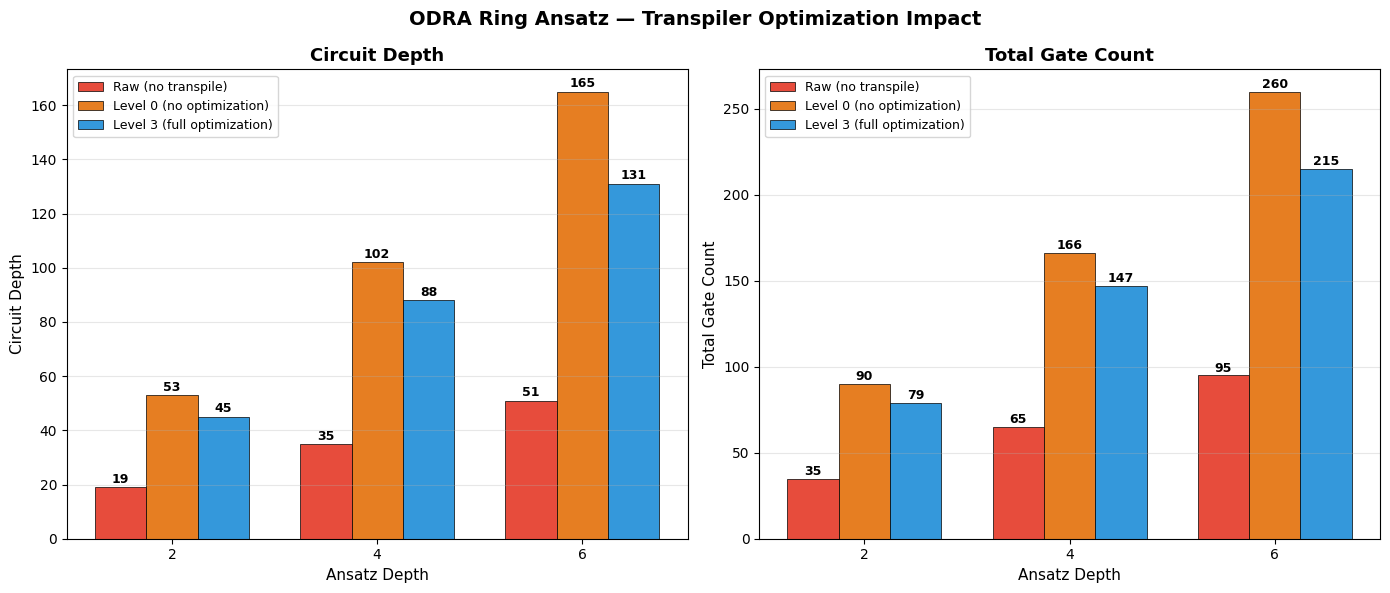

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ODRA Ring Ansatz — Transpiler Optimization Impact', fontsize=14, fontweight='bold')

colors = {'raw': '#e74c3c', 'level_0': '#e67e22', 'level_3': '#3498db'}
labels_map = {'raw': 'Raw (no transpile)', 'level_0': 'Level 0 (no optimization)', 'level_3': 'Level 3 (full optimization)'}
versions = ['raw', 'level_0', 'level_3']

for ax_idx, (metric, ylabel) in enumerate([('depth', 'Circuit Depth'), ('total_gates', 'Total Gate Count')]):
    ax = axes[ax_idx]
    x = np.arange(len(DEPTHS))
    width = 0.25
    for i, ver in enumerate(versions):
        values = [depth_stats[d][ver][metric] for d in DEPTHS]
        bars = ax.bar(x + i * width, values, width, label=labels_map[ver],
                      color=colors[ver], edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xlabel('Ansatz Depth', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(DEPTHS)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **2Q Gates (CZ) per Depth**

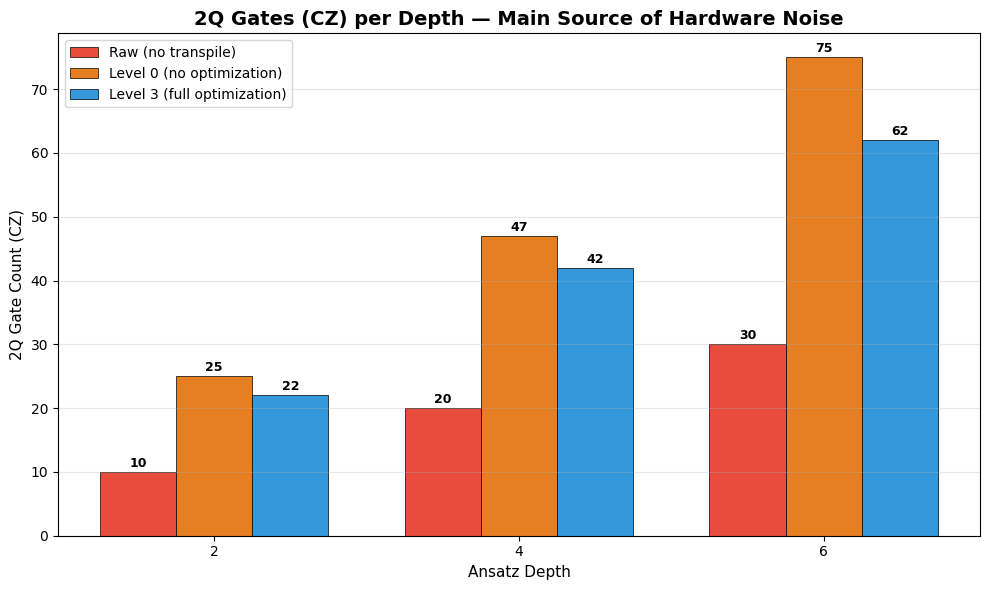

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('2Q Gates (CZ) per Depth — Main Source of Hardware Noise', fontsize=14, fontweight='bold')
x = np.arange(len(DEPTHS))
width = 0.25
for i, ver in enumerate(versions):
    values = [depth_stats[d][ver]['2q_gates'] for d in DEPTHS]
    bars = ax.bar(x + i * width, values, width, label=labels_map[ver],
                  color=colors[ver], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Ansatz Depth', fontsize=11)
ax.set_ylabel('2Q Gate Count (CZ)', fontsize=11)
ax.set_xticks(x + width)
ax.set_xticklabels(DEPTHS)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## **Simulator Inference — Accuracy & Time per Depth**

Evaluate each depth on the noiseless simulator with pre-trained weights.

In [25]:
sim_results = {}

for d in DEPTHS:
    print(f'Evaluating depth={d}...')
    model_sim = HybridModel(ansatz(NUM_QUBITS, d), NUM_QUBITS)
    model_sim.load_state_dict(torch.load(f'weights{d}.pth', map_location='cpu', weights_only=False))
    model_sim.eval()

    start = time.time()
    with torch.no_grad():
        outputs = model_sim(X_test_tensor)
    sim_time = time.time() - start

    predicted = (outputs > 0).float() * 2 - 1
    accuracy = (predicted.squeeze() == y_test_tensor.squeeze()).float().mean().item()
    sim_results[d] = {'accuracy': accuracy, 'time': sim_time}
    print(f'  Accuracy: {accuracy:.4f}, Time: {sim_time:.2f}s')

print('\n=== Simulator Results ===')
for d in DEPTHS:
    r = sim_results[d]
    print(f'  depth={d}: accuracy={r["accuracy"]:.4f}, time={r["time"]:.2f}s')

Evaluating depth=2...
  Accuracy: 0.8764, Time: 0.13s
Evaluating depth=4...
  Accuracy: 0.9455, Time: 0.21s
Evaluating depth=6...
  Accuracy: 0.9418, Time: 0.31s

=== Simulator Results ===
  depth=2: accuracy=0.8764, time=0.13s
  depth=4: accuracy=0.9455, time=0.21s
  depth=6: accuracy=0.9418, time=0.31s


## **Simulator Plots**

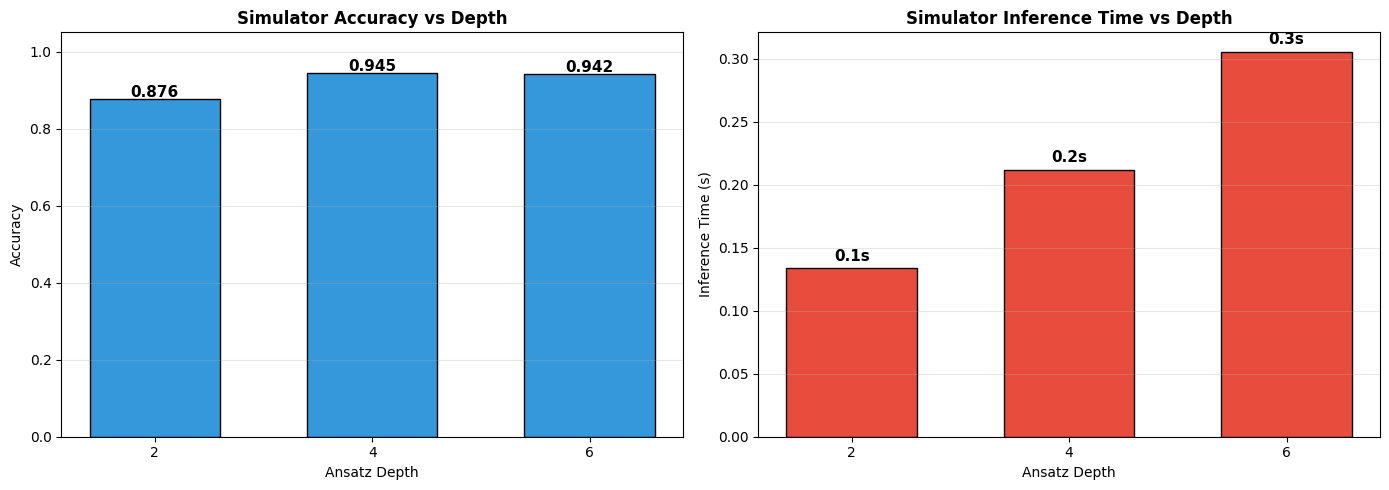

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

accs = [sim_results[d]['accuracy'] for d in DEPTHS]
axes[0].bar(DEPTHS, accs, color='#3498db', edgecolor='black', width=1.2)
for d, a in zip(DEPTHS, accs):
    axes[0].text(d, a + 0.005, f'{a:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Ansatz Depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Simulator Accuracy vs Depth', fontweight='bold')
axes[0].set_xticks(DEPTHS)
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

times = [sim_results[d]['time'] for d in DEPTHS]
axes[1].bar(DEPTHS, times, color='#e74c3c', edgecolor='black', width=1.2)
for d, t in zip(DEPTHS, times):
    axes[1].text(d, t + max(times)*0.02, f'{t:.1f}s', ha='center', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Ansatz Depth')
axes[1].set_ylabel('Inference Time (s)')
axes[1].set_title('Simulator Inference Time vs Depth', fontweight='bold')
axes[1].set_xticks(DEPTHS)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## **ODRA 5 — Hardware Inference: Level 0 vs Level 3**

For each depth, build the model with pre-trained weights, run inference on ODRA with `optimization_level=0` and `optimization_level=3`, measure execution times.

In [27]:
sample_idx = 67
sample_input = X_test_tensor[sample_idx]
actual_label = y_test_tensor[sample_idx].item()
print(f'Using test sample #{sample_idx}, actual label: {int(actual_label)}')

odra_depth_results = {}

for d in DEPTHS:
    print(f'\n{"="*60}')
    print(f'DEPTH = {d}')
    print(f'{"="*60}')

    # Build simulator model & load trained weights
    sim_model = HybridModel(ansatz(NUM_QUBITS, d), NUM_QUBITS)
    sim_model.load_state_dict(torch.load(f'weights{d}.pth', map_location='cpu', weights_only=False))
    sim_model.eval()

    obs = SparsePauliOp.from_list([("I" * (NUM_QUBITS - 1) + "Z", 1)])

    # ---- Level 0 (no optimization) ----
    print('\n--- Level 0 (no optimization) ---')
    hw_est_l0 = IQMBackendEstimator(iqm_backend, options={'shots': SHOTS}, optimization_level=0)

    hw_ansatz_l0 = ansatz(NUM_QUBITS, d)
    hw_fm_l0 = sim_model._create_angle_encoding(NUM_QUBITS)
    hw_qc_l0 = QuantumCircuit(NUM_QUBITS)
    hw_qc_l0.compose(hw_fm_l0, qubits=range(NUM_QUBITS), inplace=True)
    hw_qc_l0.compose(hw_ansatz_l0, inplace=True)

    hw_qnn_l0 = EstimatorQNN(
        circuit=hw_qc_l0, observables=obs,
        input_params=list(hw_fm_l0.parameters),
        weight_params=list(hw_ansatz_l0.parameters),
        estimator=hw_est_l0
    )
    iqm_model_l0 = TorchConnector(hw_qnn_l0)
    iqm_model_l0.load_state_dict(sim_model.quantum_layer.state_dict())

    start = time.time()
    with torch.no_grad():
        pred_l0 = iqm_model_l0(sample_input)
    time_l0 = time.time() - start

    # ---- Level 3 (full optimization) ----
    print('\n--- Level 3 (full optimization) ---')
    hw_est_l3 = IQMBackendEstimator(iqm_backend, options={'shots': SHOTS}, optimization_level=3)

    hw_ansatz_l3 = ansatz(NUM_QUBITS, d)
    hw_fm_l3 = sim_model._create_angle_encoding(NUM_QUBITS)
    hw_qc_l3 = QuantumCircuit(NUM_QUBITS)
    hw_qc_l3.compose(hw_fm_l3, qubits=range(NUM_QUBITS), inplace=True)
    hw_qc_l3.compose(hw_ansatz_l3, inplace=True)

    hw_qnn_l3 = EstimatorQNN(
        circuit=hw_qc_l3, observables=obs,
        input_params=list(hw_fm_l3.parameters),
        weight_params=list(hw_ansatz_l3.parameters),
        estimator=hw_est_l3
    )
    iqm_model_l3 = TorchConnector(hw_qnn_l3)
    iqm_model_l3.load_state_dict(sim_model.quantum_layer.state_dict())

    start = time.time()
    with torch.no_grad():
        pred_l3 = iqm_model_l3(sample_input)
    time_l3 = time.time() - start

    # Get circuit stats from backend
    t0_qc = transpile(hw_qc_l0, iqm_backend, optimization_level=0)
    t3_qc = transpile(hw_qc_l3, iqm_backend, optimization_level=3)

    odra_depth_results[d] = {
        'depth_l0': t0_qc.depth(), 'depth_l3': t3_qc.depth(),
        'gates_l0': sum(t0_qc.count_ops().values()),
        'gates_l3': sum(t3_qc.count_ops().values()),
        'cz_l0': t0_qc.count_ops().get('cz', 0),
        'cz_l3': t3_qc.count_ops().get('cz', 0),
        'time_l0': time_l0, 'time_l3': time_l3,
        'pred_l0': pred_l0.item(), 'pred_l3': pred_l3.item(),
    }

    print(f'\n  Level 0: depth={t0_qc.depth()}, gates={sum(t0_qc.count_ops().values())}, CZ={t0_qc.count_ops().get("cz",0)}, time={time_l0:.2f}s, pred={pred_l0.item():.4f}')
    print(f'  Level 3: depth={t3_qc.depth()}, gates={sum(t3_qc.count_ops().values())}, CZ={t3_qc.count_ops().get("cz",0)}, time={time_l3:.2f}s, pred={pred_l3.item():.4f}')

Using test sample #67, actual label: -1

DEPTH = 2

--- Level 0 (no optimization) ---


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

TIME ON QPU: 194.40ms | Compilation: 55.32ms | Job overall: 2.219s

--- Level 3 (full optimization) ---


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

TIME ON QPU: 161.42ms | Compilation: 71.46ms | Job overall: 2.177s

  Level 0: depth=52, gates=90, CZ=25, time=2.62s, pred=-0.1400
  Level 3: depth=45, gates=79, CZ=22, time=2.66s, pred=0.1600

DEPTH = 4

--- Level 0 (no optimization) ---


...

TIME ON QPU: 204.07ms | Compilation: 144.65ms | Job overall: 2.204s

  Level 0: depth=114, gates=184, CZ=53, time=2.62s, pred=0.1000
  Level 3: depth=88, gates=147, CZ=42, time=2.65s, pred=-0.0200

DEPTH = 6

--- Level 0 (no optimization) ---


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

TIME ON QPU: 161.55ms | Compilation: 84.38ms | Job overall: 2.218s

--- Level 3 (full optimization) ---


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

TIME ON QPU: 163.19ms | Compilation: 82.81ms | Job overall: 2.205s

  Level 0: depth=150, gates=242, CZ=69, time=2.64s, pred=0.3400
  Level 3: depth=131, gates=215, CZ=62, time=2.65s, pred=0.2800


## **ODRA 5 Results Summary & Plots**

=== ODRA 5 Timing Summary ===
Depth   Time L0 (s)    Time L3 (s)    Depth L0   Depth L3   CZ L0    CZ L3   
2       2.62           2.66           52         45         25       22      
4       2.62           2.65           114        88         53       42      
6       2.64           2.65           150        131        69       62      


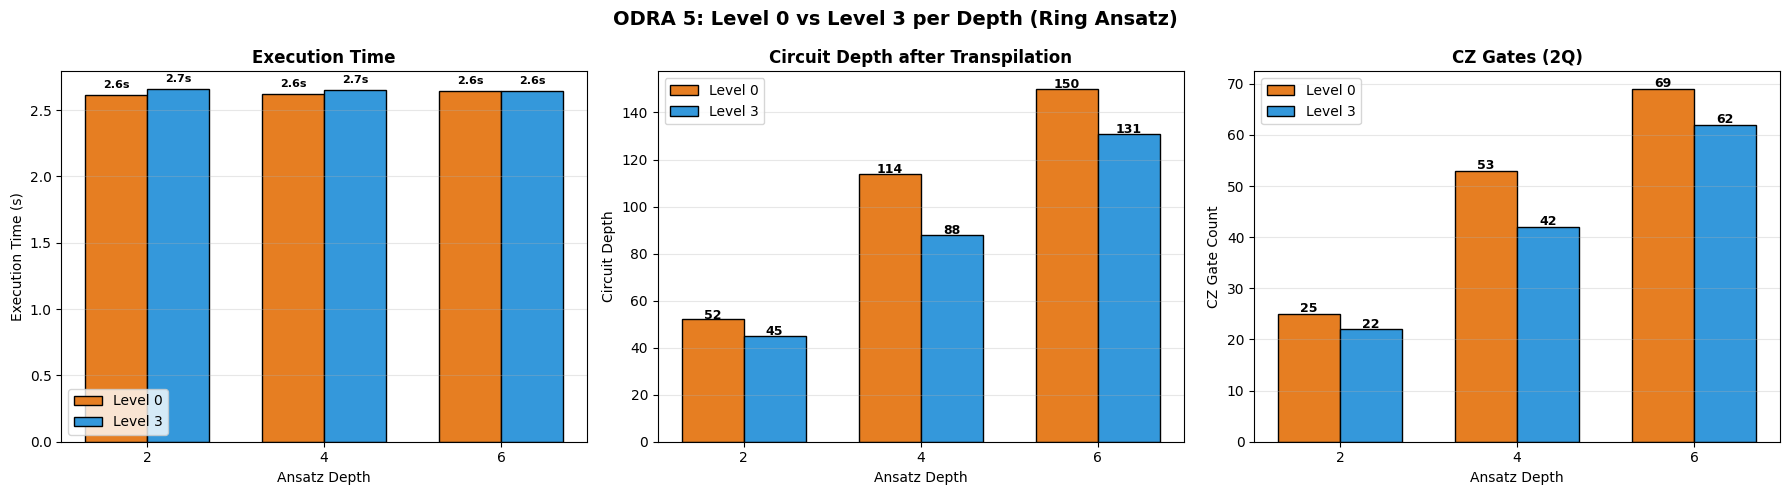

In [28]:
print('=== ODRA 5 Timing Summary ===')
print(f"{'Depth':<7} {'Time L0 (s)':<14} {'Time L3 (s)':<14} {'Depth L0':<10} {'Depth L3':<10} {'CZ L0':<8} {'CZ L3':<8}")
print('=' * 71)
for d in DEPTHS:
    r = odra_depth_results[d]
    print(f"{d:<7} {r['time_l0']:<14.2f} {r['time_l3']:<14.2f} {r['depth_l0']:<10} {r['depth_l3']:<10} {r['cz_l0']:<8} {r['cz_l3']:<8}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ODRA 5: Level 0 vs Level 3 per Depth (Ring Ansatz)', fontsize=14, fontweight='bold')

x = np.arange(len(DEPTHS))
width = 0.35

# Execution Time
t_l0 = [odra_depth_results[d]['time_l0'] for d in DEPTHS]
t_l3 = [odra_depth_results[d]['time_l3'] for d in DEPTHS]
axes[0].bar(x - width/2, t_l0, width, label='Level 0', color='#e67e22', edgecolor='black')
axes[0].bar(x + width/2, t_l3, width, label='Level 3', color='#3498db', edgecolor='black')
for i, (v0, v3) in enumerate(zip(t_l0, t_l3)):
    axes[0].text(i - width/2, v0 + max(t_l0)*0.02, f'{v0:.1f}s', ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i + width/2, v3 + max(t_l3)*0.02, f'{v3:.1f}s', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xlabel('Ansatz Depth')
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Execution Time', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(DEPTHS)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Circuit Depth
d_l0 = [odra_depth_results[d]['depth_l0'] for d in DEPTHS]
d_l3 = [odra_depth_results[d]['depth_l3'] for d in DEPTHS]
axes[1].bar(x - width/2, d_l0, width, label='Level 0', color='#e67e22', edgecolor='black')
axes[1].bar(x + width/2, d_l3, width, label='Level 3', color='#3498db', edgecolor='black')
for i, (v0, v3) in enumerate(zip(d_l0, d_l3)):
    axes[1].text(i - width/2, v0 + 0.3, str(v0), ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + width/2, v3 + 0.3, str(v3), ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Ansatz Depth')
axes[1].set_ylabel('Circuit Depth')
axes[1].set_title('Circuit Depth after Transpilation', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(DEPTHS)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# CZ Gates
cz_l0 = [odra_depth_results[d]['cz_l0'] for d in DEPTHS]
cz_l3 = [odra_depth_results[d]['cz_l3'] for d in DEPTHS]
axes[2].bar(x - width/2, cz_l0, width, label='Level 0', color='#e67e22', edgecolor='black')
axes[2].bar(x + width/2, cz_l3, width, label='Level 3', color='#3498db', edgecolor='black')
for i, (v0, v3) in enumerate(zip(cz_l0, cz_l3)):
    axes[2].text(i - width/2, v0 + 0.3, str(v0), ha='center', fontsize=9, fontweight='bold')
    axes[2].text(i + width/2, v3 + 0.3, str(v3), ha='center', fontsize=9, fontweight='bold')
axes[2].set_xlabel('Ansatz Depth')
axes[2].set_ylabel('CZ Gate Count')
axes[2].set_title('CZ Gates (2Q)', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(DEPTHS)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **Gate Breakdown (Level 3)**

Native gate counts after Level 3 transpilation per depth.

In [29]:
print('Gate breakdown after Level 3 transpilation (native ODRA 5 gates):')
print('=' * 60)
for d in DEPTHS:
    print(f"  depth={d}: {depth_stats[d]['level_3']['ops']}")

Gate breakdown after Level 3 transpilation (native ODRA 5 gates):
  depth=2: {'r': 57, 'cz': 22}
  depth=4: {'r': 105, 'cz': 42}
  depth=6: {'r': 153, 'cz': 62}
